In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from sklearn.metrics import classification_report
import statsmodels.api as sm
import sys
import shap
import math
import xgboost as xgb
sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)
from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve
import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'

file1 = r'E:\Drive\NOA\MBD-Prediction\Grid Level\data\GR_WNV_Dataset_GRID_OP_2010_2021.csv'

dataset = read_data(file1)

dataset.head()

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(664560, 92)


In [2]:
dataset.head()

,cell_code,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type,cases
0,AAE407,EL43,EL434,αποκορωνου,2010,1,24.117404,35.410691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.105484,12.522258,13.950714,19.048065,22.682667,9.001613,9.339677,7.253571,9.301613,11.206,10.553548,10.930968,10.602143,14.174839,16.944333,3.110,20.630,10.158791,8.697677,20.032296,307.352892,449.754390,19.250000,18.666667,47.863248,773.275207,42.0,3.0,39.0,10.666667,29.000000,29.000000,10.500000,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,22,20,20,9,9,4,1,1,6585.886993,178.967214,11,129.520913,259.412149,167.327918,0.000000,52.950027,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
1,AAE468,EL43,EL433,μυλοποταμου,2010,1,24.789225,35.408170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.274,18.134,8.900615,5.977331,8.328200,275.917567,363.227389,16.833333,20.500000,50.000000,796.107957,41.0,0.0,41.0,8.500000,27.333333,27.333333,7.833333,1746.0,328.0,0.0,81.286010,818.0,1.0,1.0,655.0,31,30,50,11,10,1,6,6,0.000000,4784.892552,13,63.847297,51.029019,188.997189,1.128647,6.233711,7596.0,27753.0,6190.0,41539.0,7371.0,28024.0,7574.0,42969.0,1457.56,2031.0,2221.0,3,3,1,0
2,AAF412,EL43,EL434,αποκορωνου,2010,1,24.172455,35.401609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.062258,13.808065,15.227857,19.090645,22.681333,9.595161,9.121613,7.030714,8.535161,10.694,11.828710,11.464839,11.129286,13.812903,16.687667,5.970,20.070,10.158791,8.697677,20.032296,307.352892,449.754390,19.458333,20.583333,46.780303,795.000953,44.0,0.0,44.0,10.500000,29.500000,29.500000,10.166667,2145.0,407.0,4.0,80.863945,1070.0,15.0,15.0,943.0,31,30,30,10,10,1,6,6,5449.996872,871.966870,11,251.863885,182.026884,183.272934,0.000000,3.239146,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
3,AAF418,EL43,EL434,αποκορωνου,2010,1,24.238531,35.401496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.268065,13.366774,14.356429,18.776452,21.927333,8.675161,8.922258,7.170000,8.628065,10.402,11.471613,11.144516,10.763214,13.702258,16.164667,5.470,19.870,9.615967,6.088871,14.048537,297.686708,442.198871,18.916667,18.833333,45.934959,773.373170,42.0,1.0,41.0,10.500000,28.666667,28.666667,10.166667,2022.0,366.0,2.0,79.439558,985.0,14.0,14.0,854.0,22,20,20,9,9,4,2,2,2072.028070,3644.010740,6,148.262387,301.797520,184.889754,0.000000,9.160420,12899.0,52814.0,11989.0,77702.0,12363.0,50340.0,14324.0,77027.0,2953.85,4278.0,4973.0,2,2,1,0
4,AAF461,EL43,EL433,μυλοποταμου,2010,1,24.712056,35.399633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.909355,13.180968,15.556429,20.501613,24.858000,9.899032,8.513226,7.876429,9.155806,10.950,13.404194,10.847097,11.716429,14.828710,17.904000,6.510,21.790,8.895365,8.553344,15.224943,275.746825,414.026678,19.416667,20.833333,49.603175,783.591189,42.0,0.0,42.0,11.000000,29.166667,29.166667,9.833333,1825.0,345.0,0.0,81.455549,855.0,4.0,4.0,707.0,31,36,30,12,12,1,6,7,2719.492211,298.312749,10,176.489002,56.734191,180.2360

In [3]:
len(dataset.cell_code.unique())

4260

In [4]:
dataset = encode_cyclical(dataset, 'month', 12)

In [5]:
dataset.cases.sum()

1364

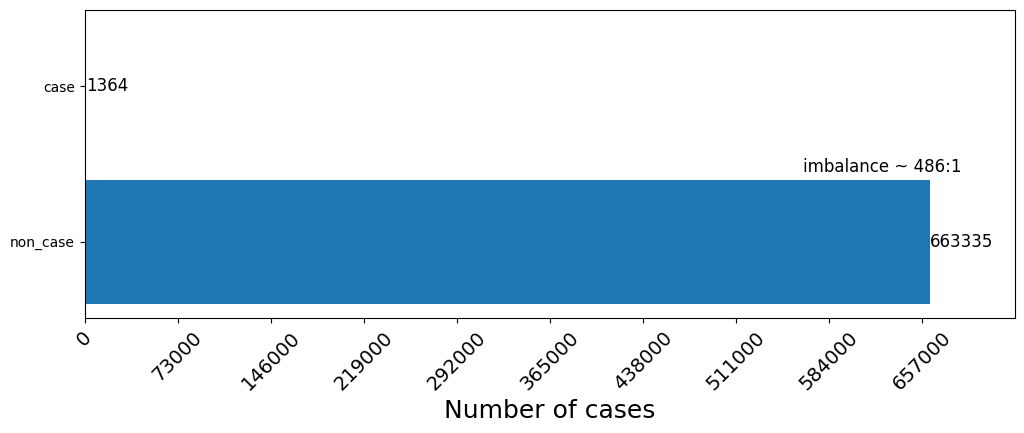

In [6]:
plot_imbalance(dataset, target_column='cases')

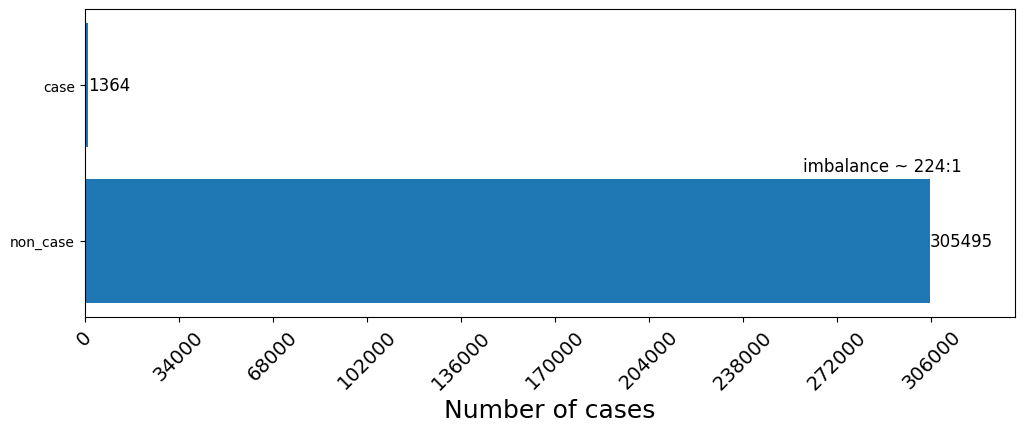

In [7]:
dataset = dataset.query('month >= 5 & month <= 10 & year <= 2021')
# dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

plot_imbalance(dataset, target_column='cases')

In [8]:
# hot_cells = dataset[dataset['cases']>0].cell_code.unique().tolist()

# dataset = dataset.query("cell_code in @hot_cells")

# dataset.reset_index(drop=True, inplace=True)

# plot_imbalance(dataset, target_column='cases')

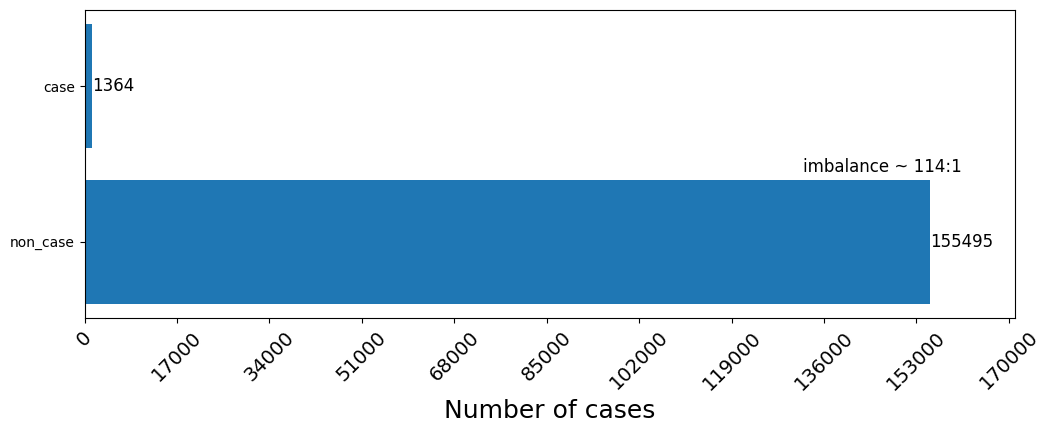

In [9]:
# rows_to_remove = dataset.query('cases == 0').sample(n=295000, random_state=0).index
rows_to_remove = dataset.query('cases == 0').sample(n=150000, random_state=0).index

dataset.drop(rows_to_remove, inplace=True)
dataset.reset_index(drop=True, inplace=True)

plot_imbalance(dataset, target_column='cases')

In [10]:
dataset.shape

(156720, 94)

In [11]:
dataset.cases.sum()

1364

In [12]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,12904,262,13166,49.25%
1,2011,12946,100,13046,129.46%
2,2012,13045,157,13202,83.09%
3,2013,12916,85,13001,151.95%
4,2014,12960,15,12975,864.00%
5,2015,12948,0,12948,inf%
6,2016,12961,0,12961,inf%
7,2017,13060,42,13102,310.95%
8,2018,12955,296,13251,43.77%
9,2019,12915,218,13133,59.24%


In [13]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

features_to_remove = ['x', 'y', 'year', 'month']
features_to_remove += ['lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',]
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lc_type1', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_15t64', 'females_gt65', 'females_t

In [14]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='cases')
    # data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "seed": 0,
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.3,          #default 0.3, range[0,1], large values lead to overfitting
        "min_split_loss": 0.3,          #default 0, range[0,inf], large values lead to underfitting
        "max_depth": 3,                 #default 6, range[0,inf], large values lead to overfitting
        "reg_alpha": 0.5,               #default 0, range[0,inf], large values lead to underfitting
        "reg_lambda": 1.5,              #default 1, range[0,inf], large values lead to underfitting
        "min_child_weight": 1.5,        #default 1, range[0,inf], large values lead to underfitting
        "scale_pos_weight": sum_negatives/sum_positives, 
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
    print(f"Test set 0/1 Ratio: {(sum_negatives / sum_positives):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)
    
    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 113.78
Test set 0/1 Ratio: 113.78
Weight: 113.78
Fold: 2/10
Training set 0/1 Ratio: 113.78
Test set 0/1 Ratio: 113.78
Weight: 113.78
Fold: 3/10
Training set 0/1 Ratio: 113.78
Test set 0/1 Ratio: 113.78
Weight: 113.78
Fold: 4/10
Training set 0/1 Ratio: 113.78
Test set 0/1 Ratio: 113.78
Weight: 113.78
Fold: 5/10
Training set 0/1 Ratio: 113.96
Test set 0/1 Ratio: 113.96
Weight: 113.96
Fold: 6/10
Training set 0/1 Ratio: 114.06
Test set 0/1 Ratio: 114.06
Weight: 114.06
Fold: 7/10
Training set 0/1 Ratio: 114.06
Test set 0/1 Ratio: 114.06
Weight: 114.06
Fold: 8/10
Training set 0/1 Ratio: 114.15
Test set 0/1 Ratio: 114.15
Weight: 114.15
Fold: 9/10
Training set 0/1 Ratio: 114.33
Test set 0/1 Ratio: 114.33
Weight: 114.33
Fold: 10/10
Training set 0/1 Ratio: 114.33
Test set 0/1 Ratio: 114.33
Weight: 114.33


In [15]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

df_test = pd.DataFrame({'score': y_test_proba[:, 1], 'target': y_test_true})

train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.1737
Test Loss: 0.1797


In [29]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_test_proba[:,1], y_test_true, beta = 3, round_factor = 2)
print(classification_thresholds)

# thr = classification_thresholds
thr = 0.77

0.77


In [30]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    155495
           1       0.13      0.65      0.21      1225

    accuracy                           0.96    156720
   macro avg       0.56      0.81      0.60    156720
weighted avg       0.99      0.96      0.97    156720



In [31]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[149951   5544]
 [   431    794]]


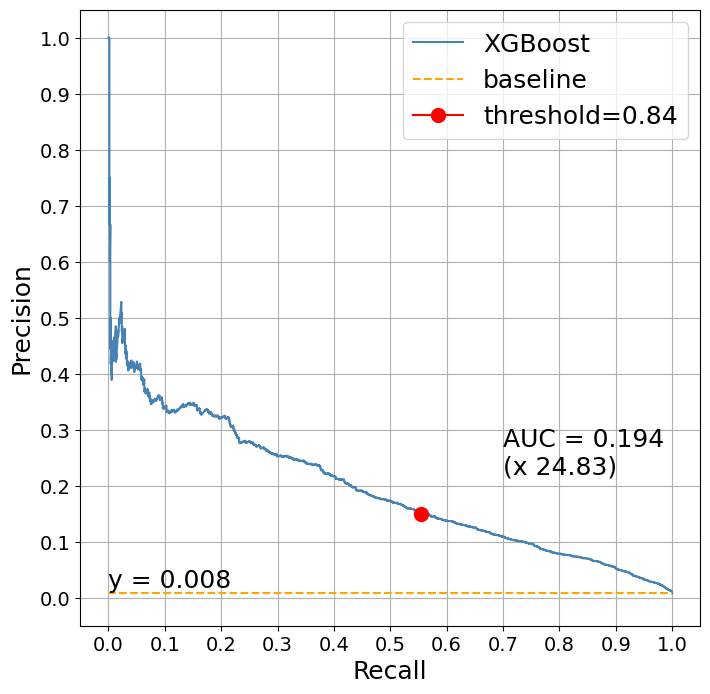

(0.5551, 0.15, 0.366, 0.84)

In [32]:
plot_pr_curve(df_test, target_col = 'target', model_name='XGBoost', plot_fbeta=True, beta = 2)

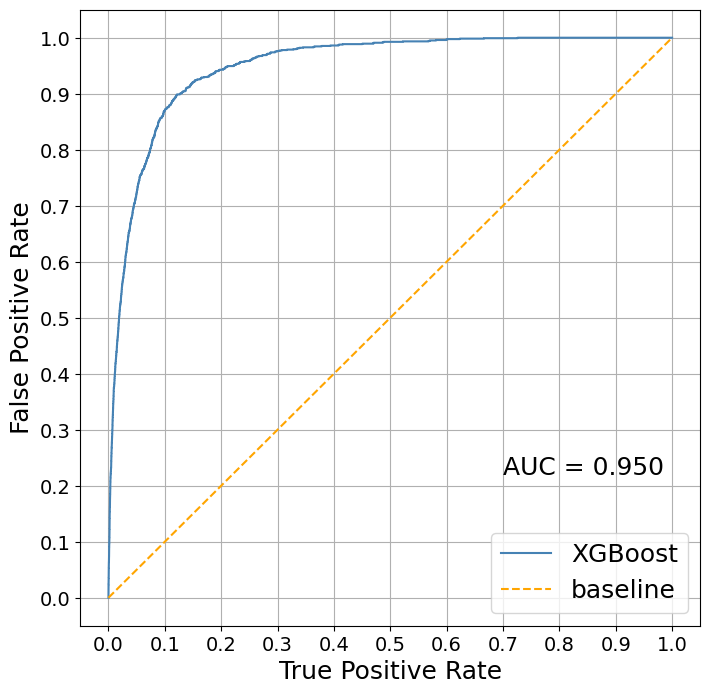

(0.1217, 0.8988, 0.8885, 0.3146)

In [33]:
plot_roc_curve(df_test, target_col = 'target', model_name='XGBoost')

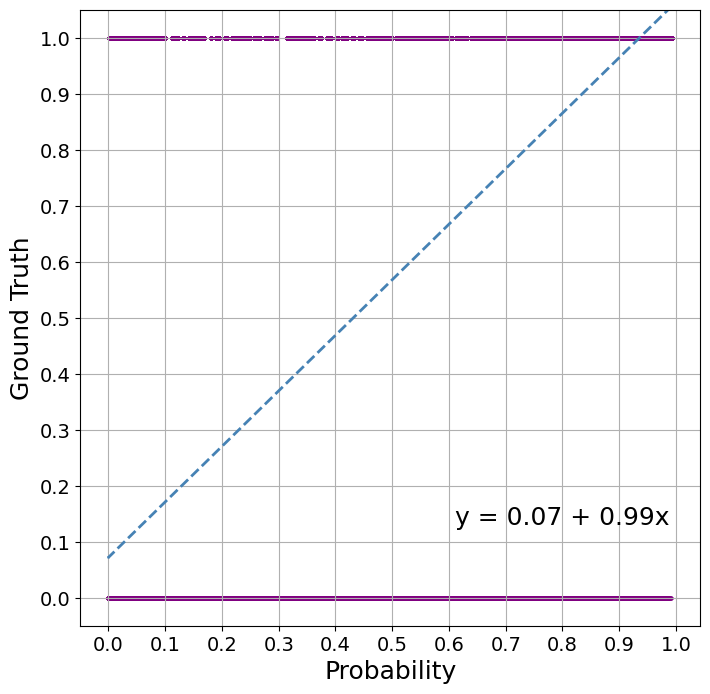

(0.07198595196497332, 0.9916601343488848)

In [35]:
plot_probability_curve(df_test, target_col = 'target', marker_size=4, marker_shape='o', augment_samples=True)

In [36]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [37]:
# Tree explainer

# curently not working with multioutput models

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [38]:
num_of_location_cols = 8

location_columns = data_train_shap.iloc[:, :num_of_location_cols]
wnv_columns = data_train_shap['cases']

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

tree_shap_values_df

# region_attica = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL30'))
# region_macedonia = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL52'))
# region_thrace = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL51'))
# region_thessaly = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL61'))

# shap_values_df_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].to_numpy()
# shap_values_df_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].to_numpy()
# shap_values_df_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].to_numpy()
# shap_values_df_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].to_numpy()

sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, num_of_location_cols:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
# sorted_mean_abs_values_idx_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index

In [39]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

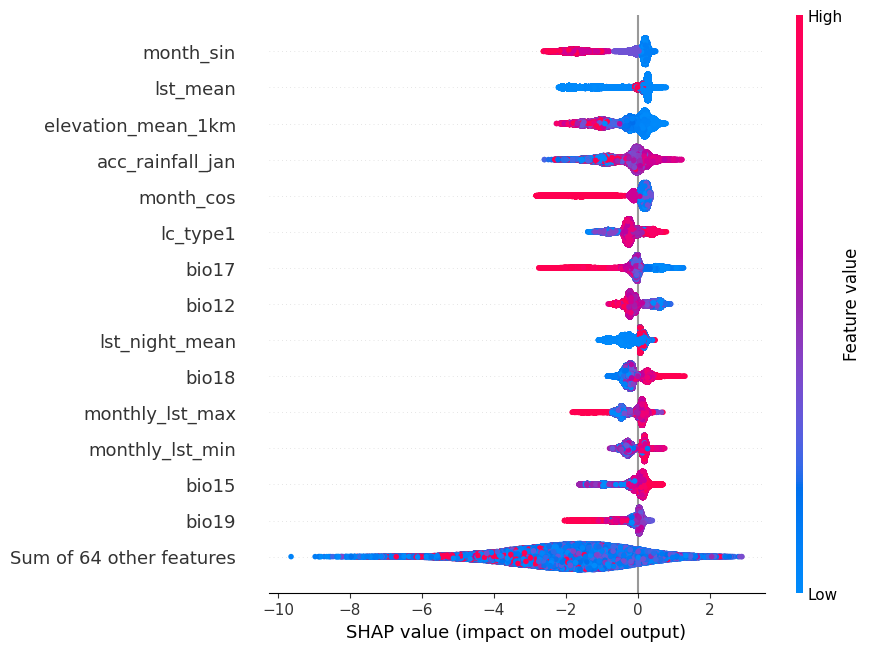

In [40]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=15)

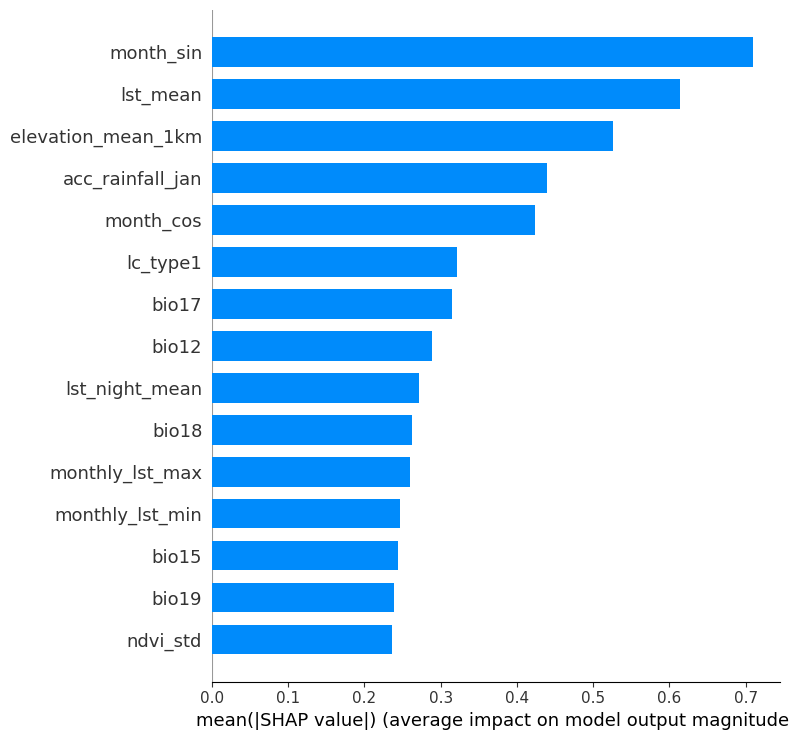

In [41]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='bar', max_display=15)

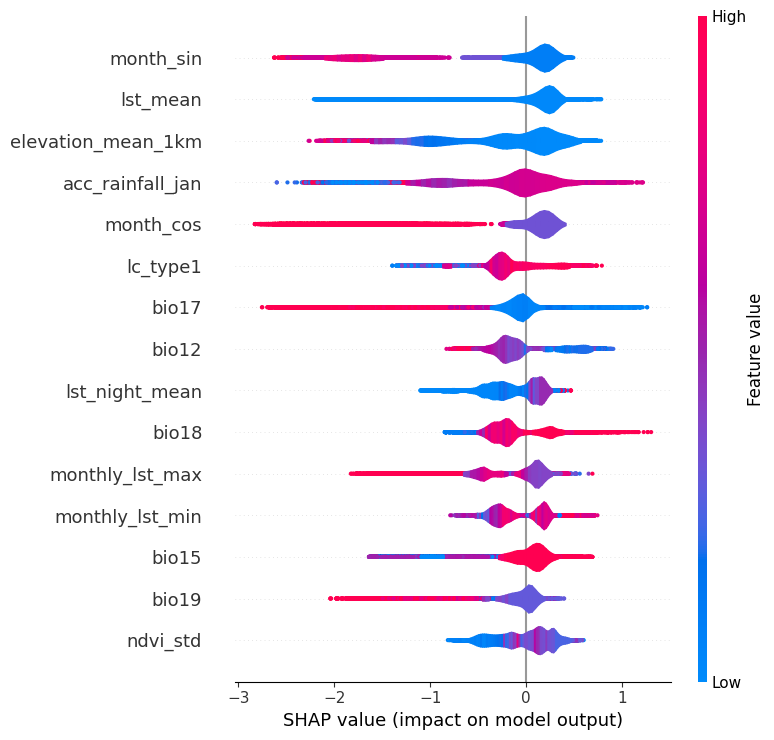

In [42]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=15)

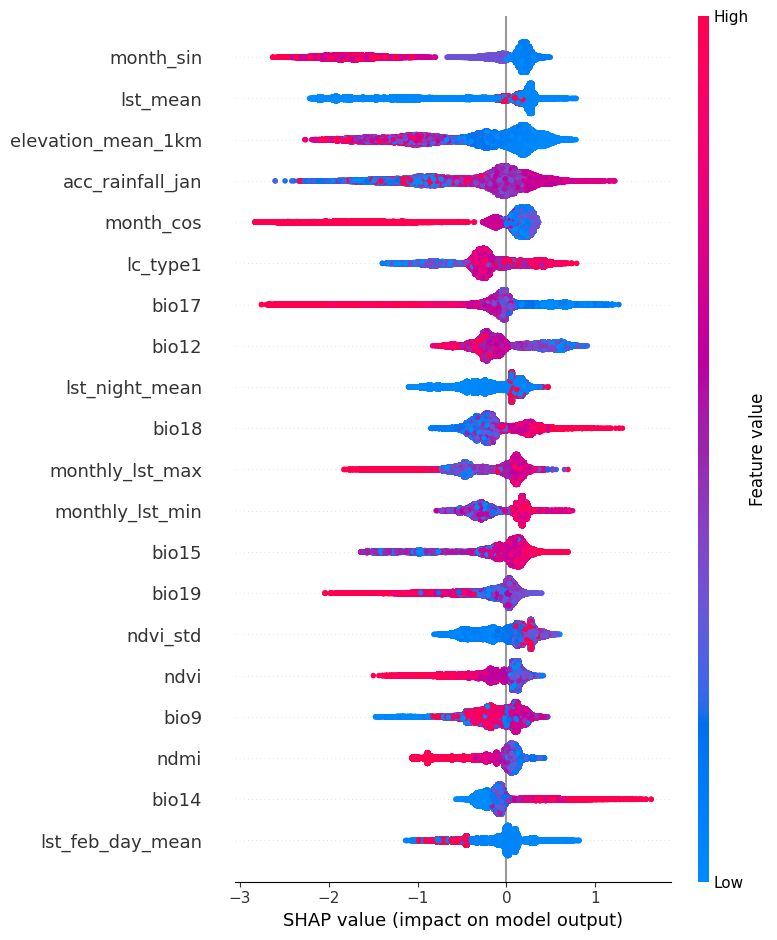

In [43]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=20)

In [44]:
shap_lim = (-3, 1.5)
lowess_it = 3
lowess_frac = 0.5
shap_alpha = 0.5

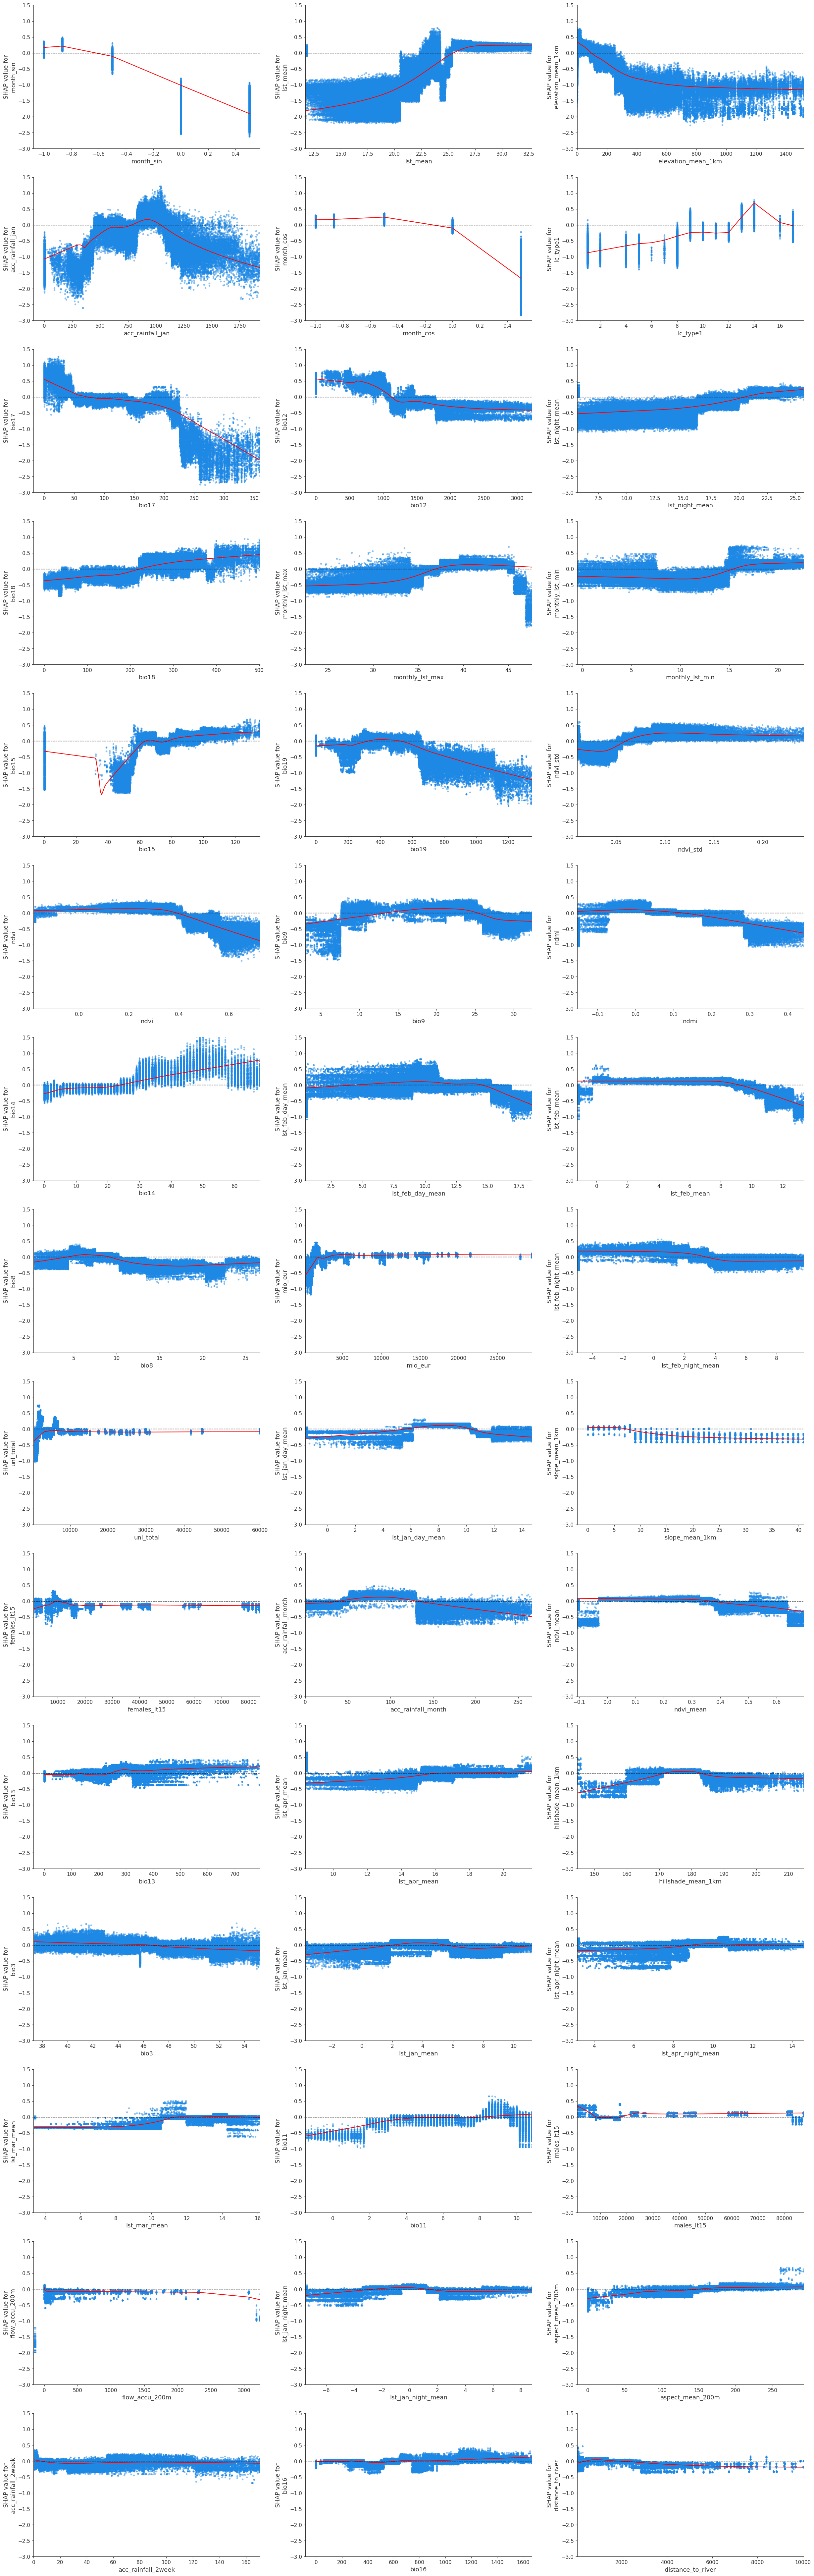

In [45]:
num_plots = 45

fig, axes = plt.subplots(15, 3, figsize=(30, 100))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = data.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it, frac=lowess_frac)
    
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=data, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=shap_alpha, ax=ax, show = False)
    
    i = i+1

plt.show()

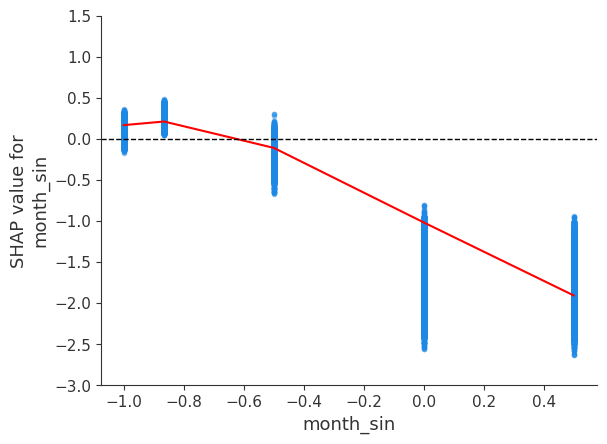

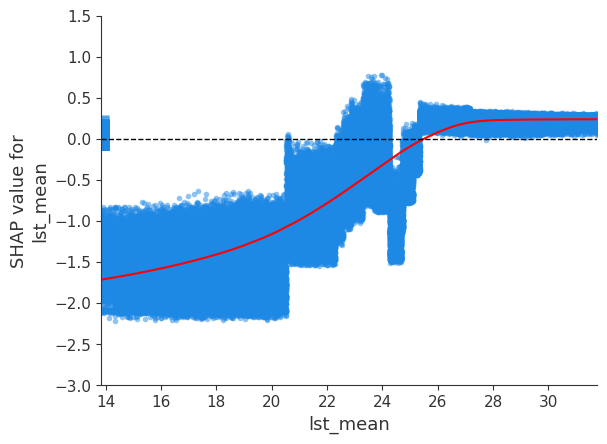

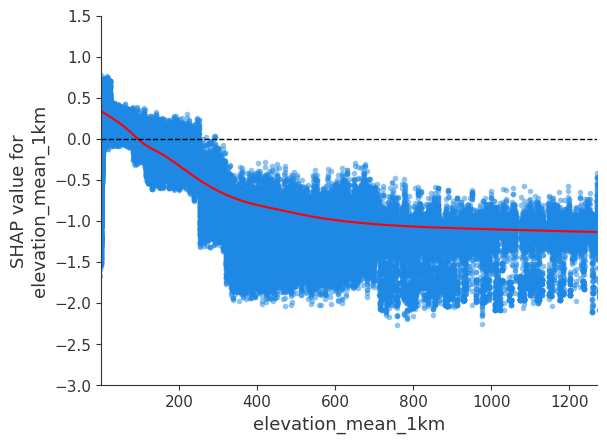

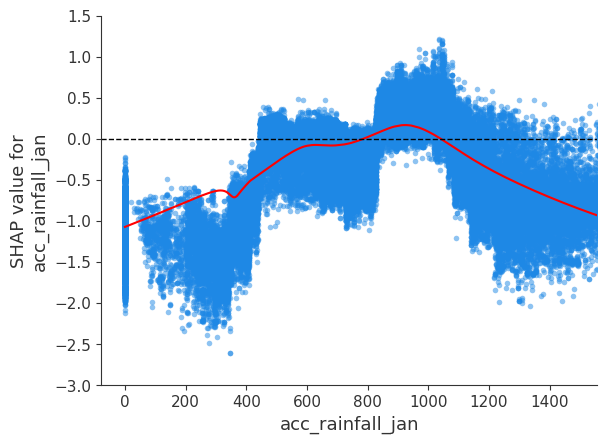

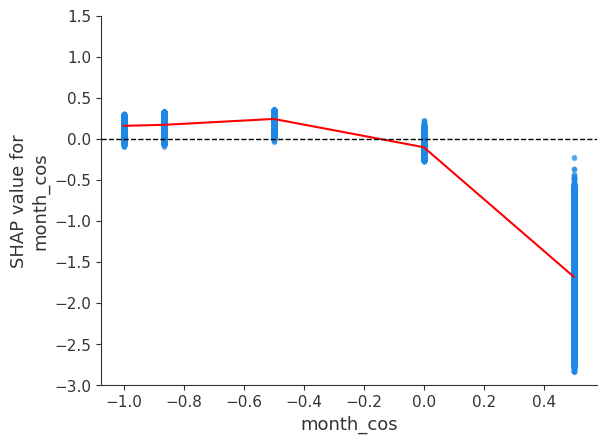

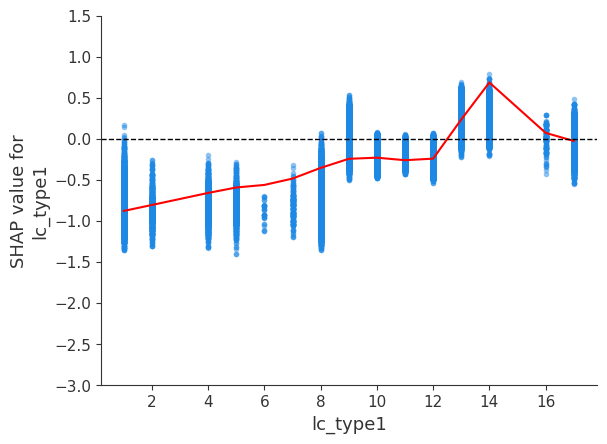

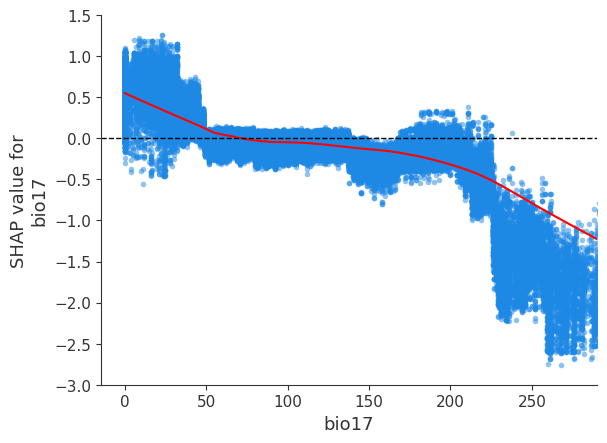

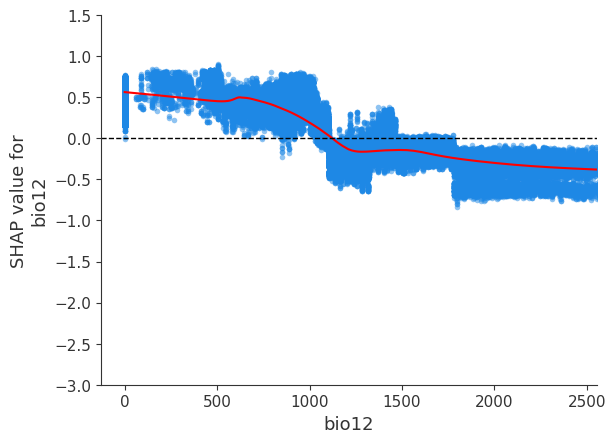

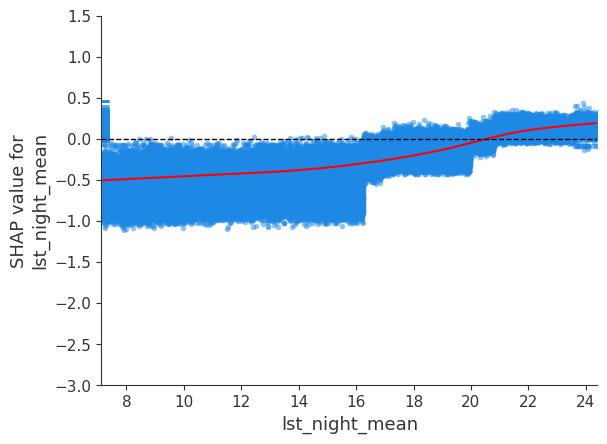

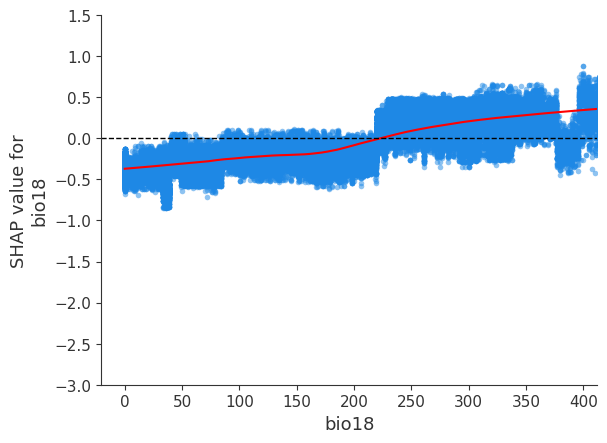

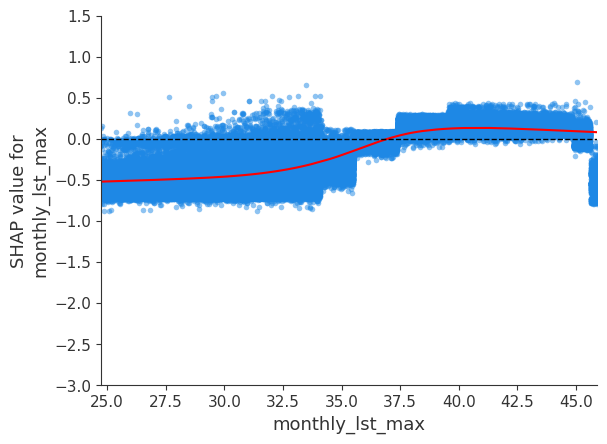

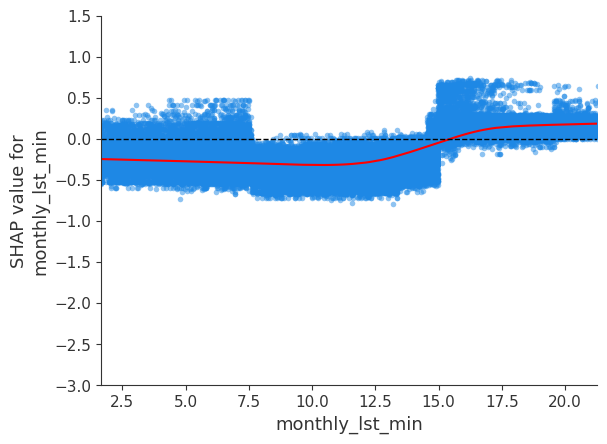

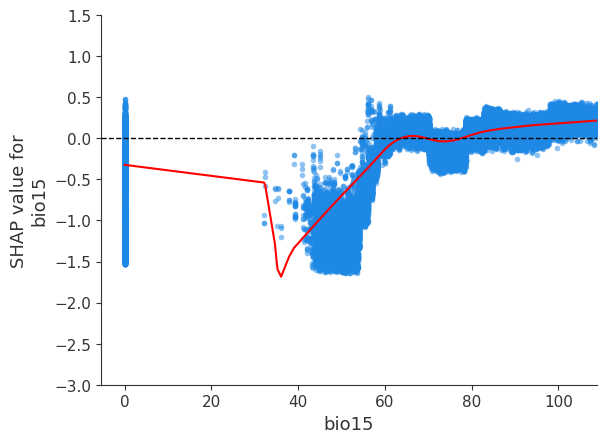

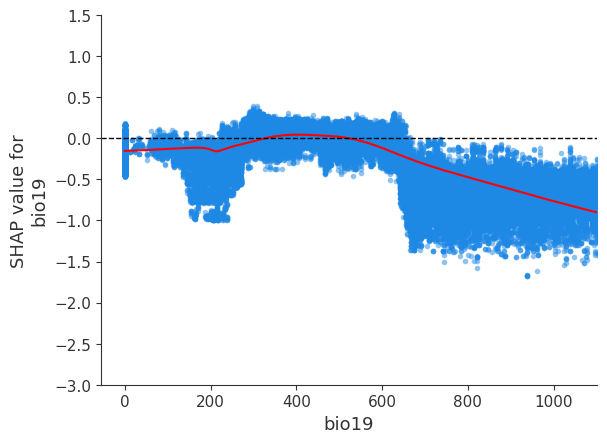

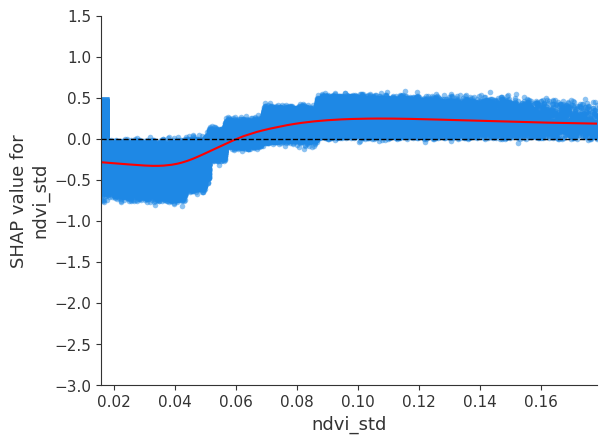

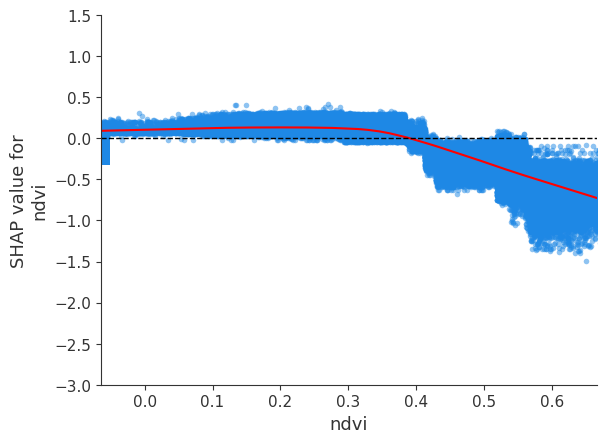

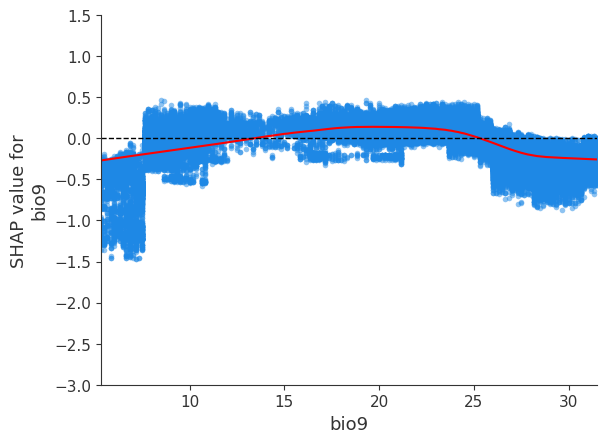

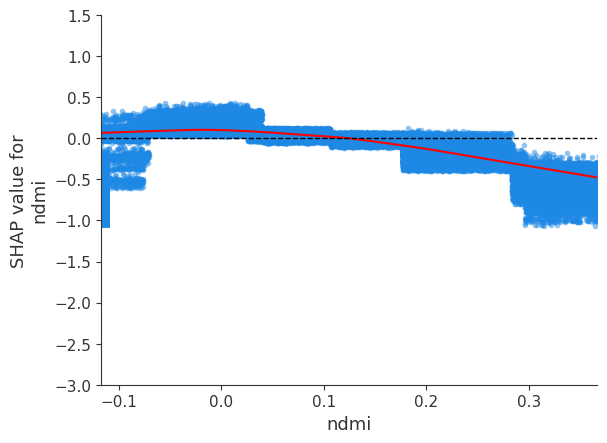

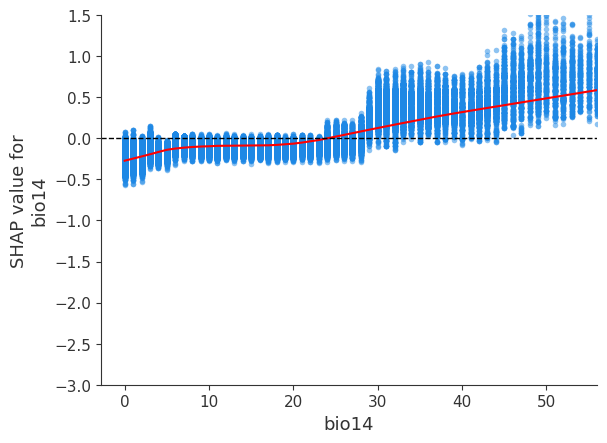

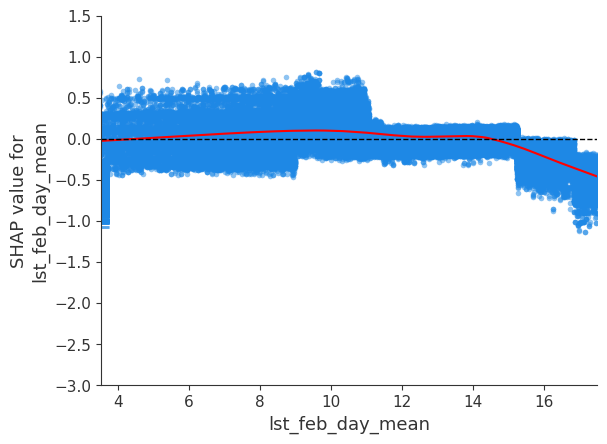

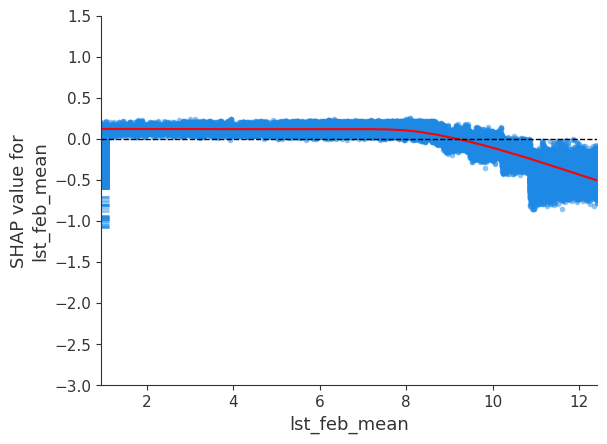

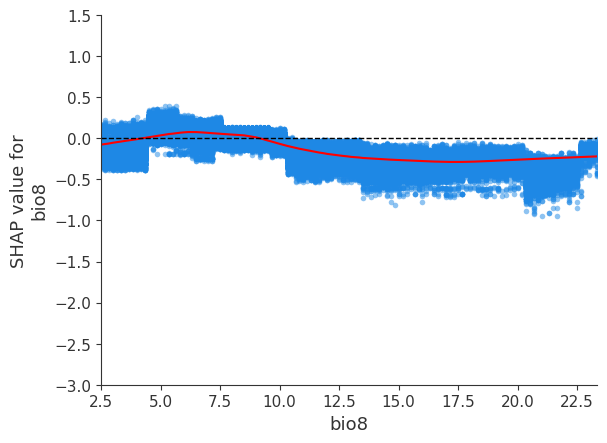

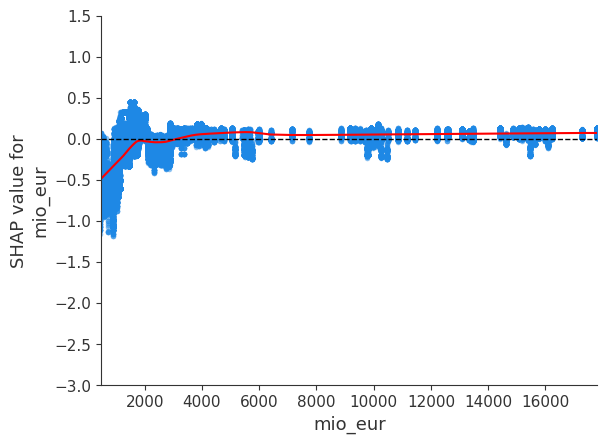

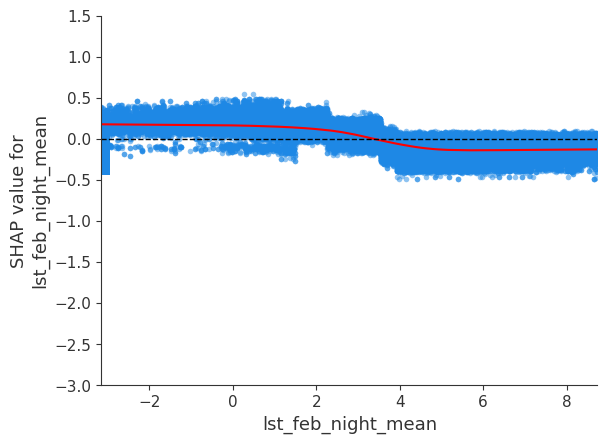

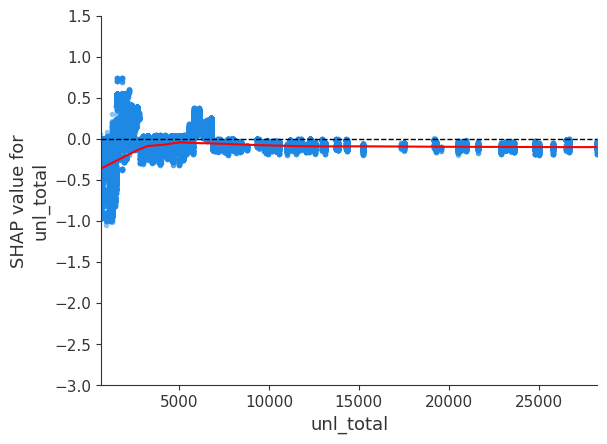

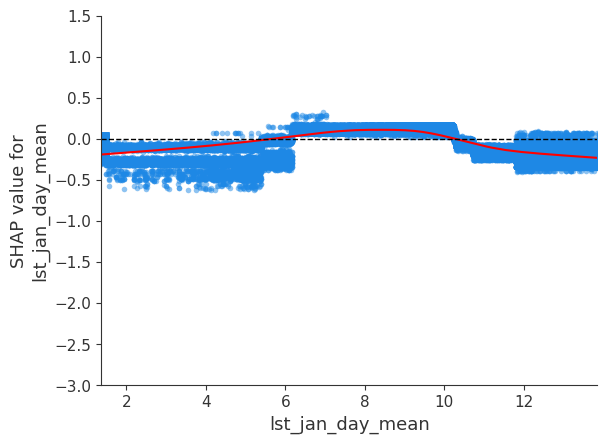

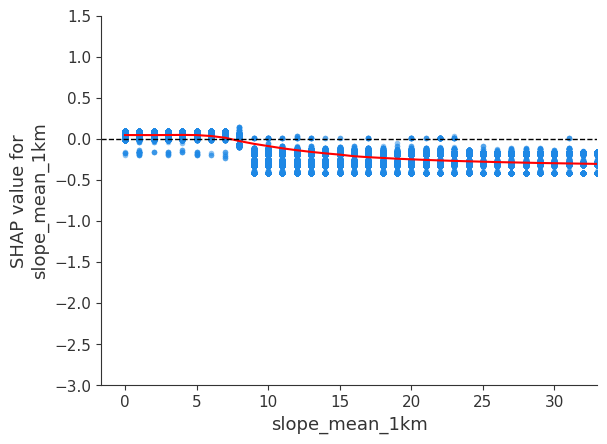

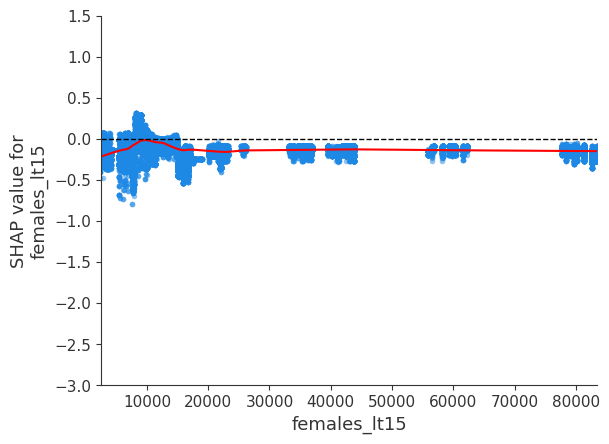

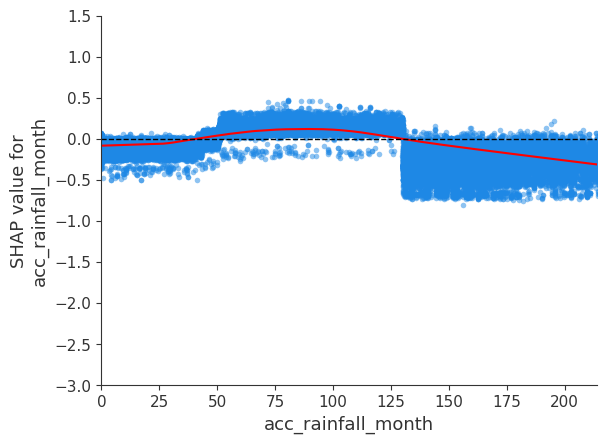

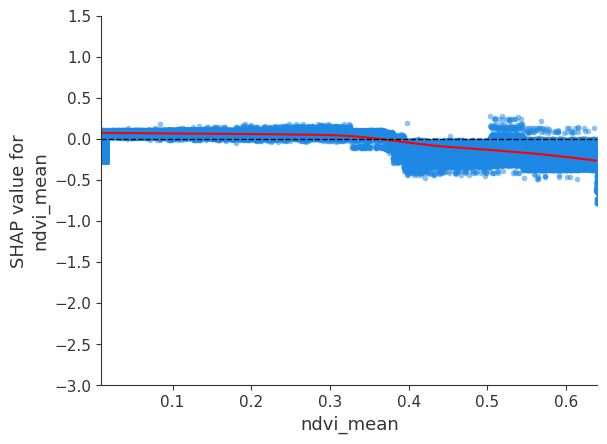

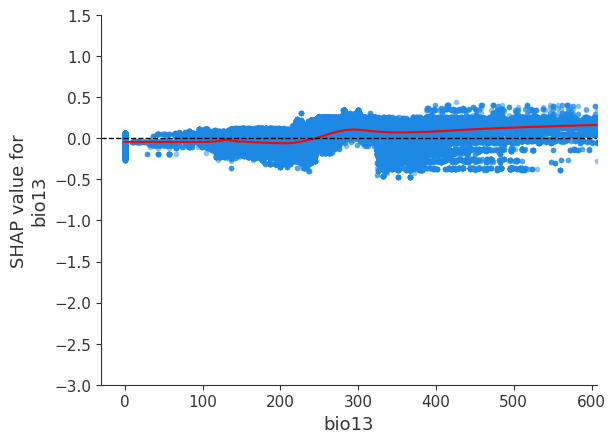

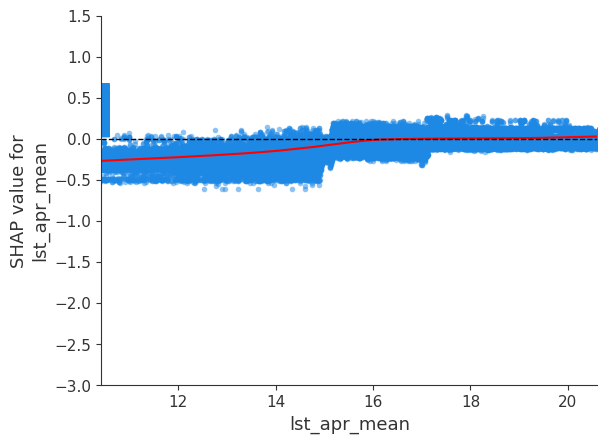

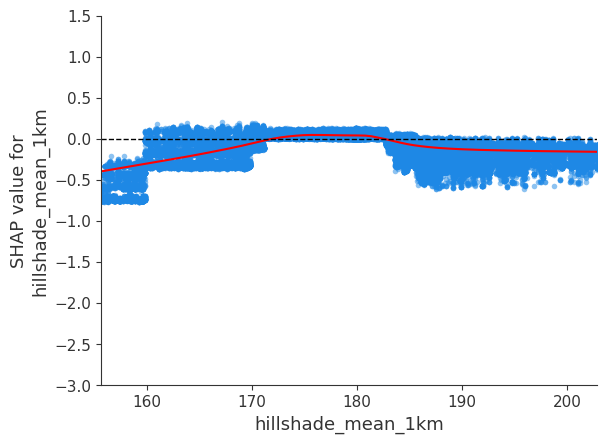

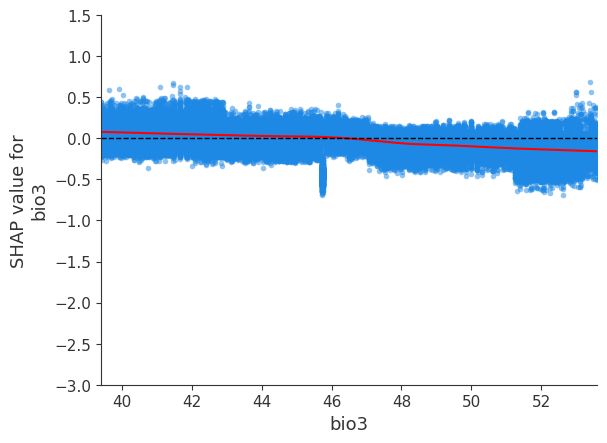

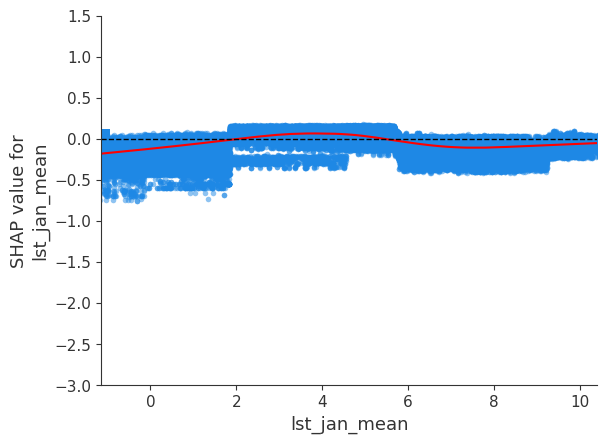

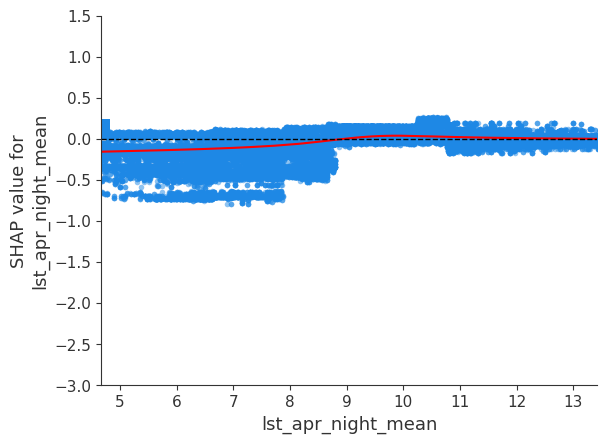

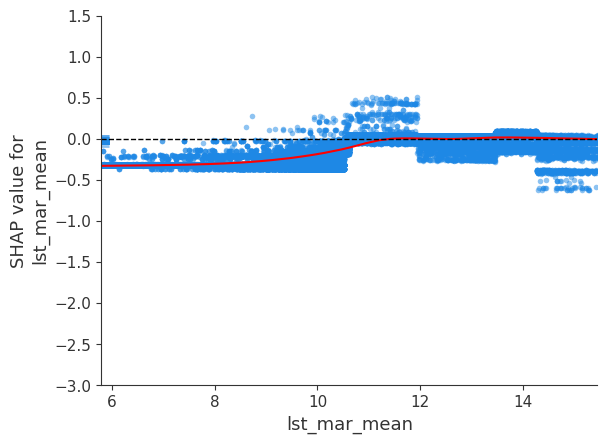

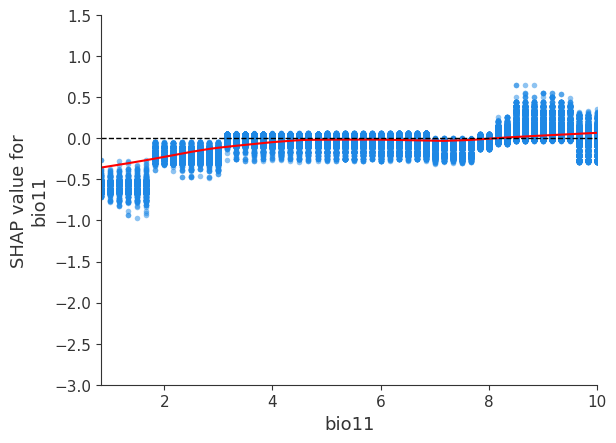

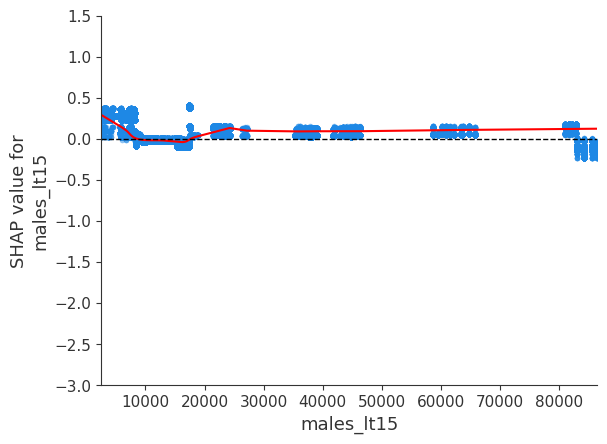

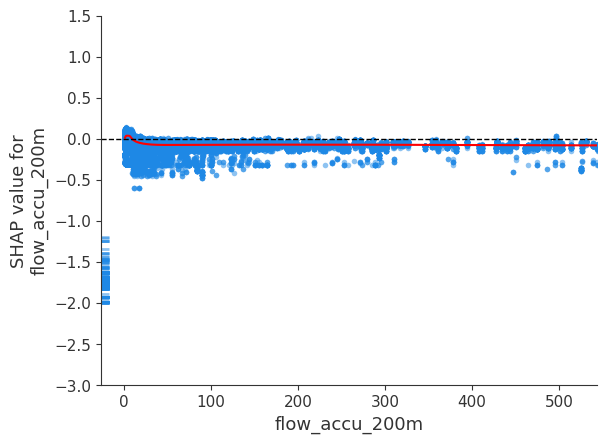

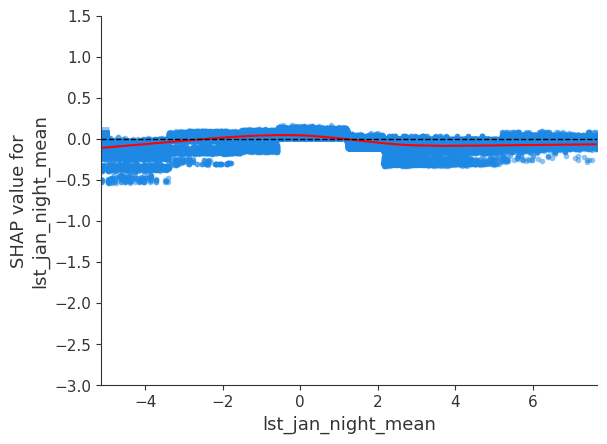

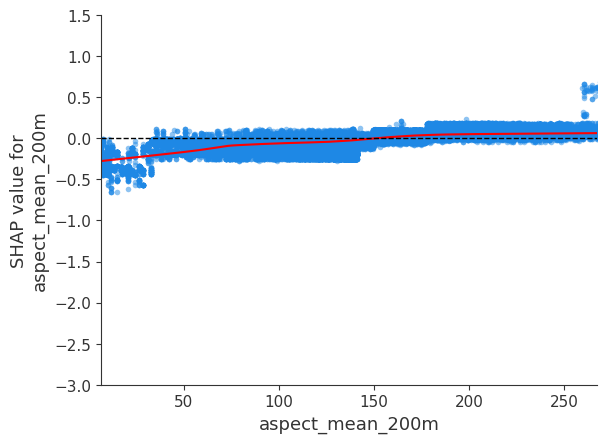

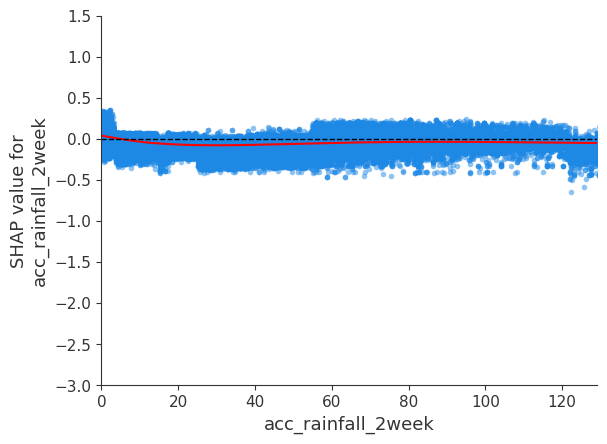

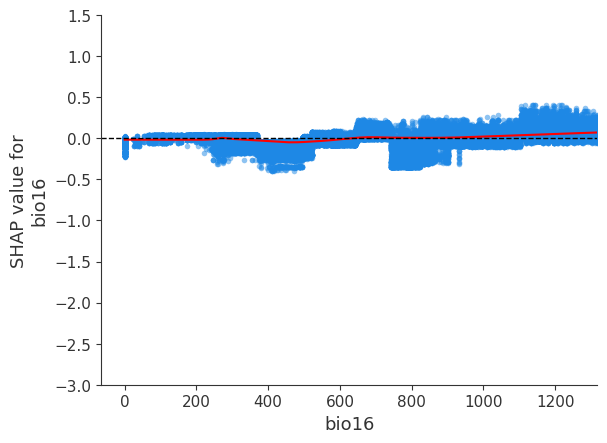

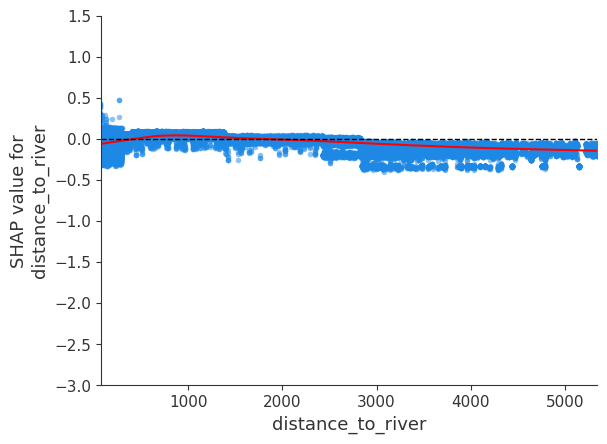

In [46]:
for ft in sorted_mean_abs_values_idx[:45]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=lowess_it,frac=lowess_frac)
    _,ax = plt.subplots()
    # ax.set_facecolor('lightgrey')
    ax.plot(*list(zip(*lowess)), color="red", lw=1.5)
    ax.axhline(y=0, color='black', linestyle='--', lw=1)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(3)", xmax="percentile(97)", alpha=shap_alpha, ax = ax)